In [15]:
import mysql.connector
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
conn = mysql.connector.connect(
    host="192.168.0.4",   
    user="farmorai_admin", 
    password="farmorai12345", 
    database="farmdb" 
)

C:\Users\KOSMO\AppData\Local\Temp\ipykernel_24388\73836929.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)
d:\final-project\farm_web_python\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 53945 (\N{HANGUL SYLLABLE TEUG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\final-project\farm_web_python\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\final-project\farm_web_python\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48372 (\N{HANGUL SYLLABLE BO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\final-project\farm_web_python\Lib\site-packages\IPython\core\pylabto

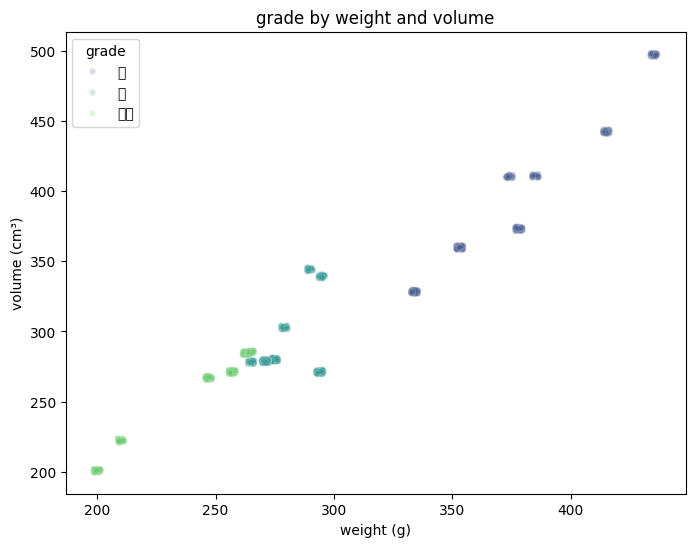

In [16]:
# 데이터 불러오기
query = "SELECT cate3, weight, height, width FROM apple_label_dataset"
df = pd.read_sql(query, conn)

# MySQL 연결 종료
conn.close()

# 부피(Volume) 계산
df["volume"] = (4/3) * np.pi * (df["width"] / 2) ** 2 * (df["height"] / 2)


# 시각화
plt.figure(figsize=(8, 6))

x_jitter = df["weight"] + np.random.uniform(-1.5, 1.5, size=len(df))
y_jitter = df["volume"] + np.random.uniform(-1.5, 1.5, size=len(df))

sns.scatterplot(x=x_jitter, y=y_jitter, hue=df["cate3"], palette="viridis",alpha=0.2, s=20)
plt.title("grade by weight and volume")
plt.xlabel("weight (g)")
plt.ylabel("volume (cm³)")
plt.legend(title="grade")
plt.show()
